In [1]:
import re
from ast import literal_eval
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# -----------------------------
# Time array
# -----------------------------
Num_step_list = np.array([3])
initial_t = 0.0
final_t = 1.0
times = []

for num_step in Num_step_list:
    total_t = 0
    delta_t = (final_t - initial_t) / num_step
    times.append(0.0)
    for _ in range(num_step):
        total_t += delta_t
        times.append(total_t)
times = np.array(times)
print("Times:", times)


# -----------------------------
# 2-qubit Pauli basis (64 operators)
# -----------------------------
Psingle = ["I", "Z"]
Pauli_combination = [(p1, p2, p3) for p1 in Psingle for p2 in Psingle for p3 in Psingle]
#print(Pauli_combination)
# Build matrices for each Pauli string
matrices = [SparsePauliOp.from_list([(p1+p2+p3, 1)]).to_matrix() for (p1, p2, p3) in Pauli_combination]

# -----------------------------
# Function to compute expectation from bitstring
# -----------------------------
def pauli_value_from_bits(P1, P2, P3, bits):
    b0 = bits[2]  # 0th bit from bits measurement
    b1 = bits[1]  # 1st bit from bits measurement
    b2 = bits[0]  # 2nd bit from bits measurement

    # Case 1: I ⊗ I ⊗ I
    if P1 == "I" and P2 == "I" and P3 == "I":
        value = 1.0
        return value
        
    # Case 2: I ⊗ I ⊗ P3
    if P1 == "I" and P2 == "I":
        value = (-1)**b2
        return  value      # only second qubit matters
    # Case 3: I ⊗ P2 ⊗ I
    elif P1 == "I" and P3 == "I":
        value = (-1)**b1
        return  value      # only first qubit matters
        
    # Case 4: P1 ⊗ I ⊗ I
    elif P2 == "I" and P3 == "I":
        value = (-1)**b0
        return value

    # Case 5: I ⊗ P2 ⊗ P3
    elif P1 == "I":
        value = (-1)**b1 * (-1)**b2 
        return value

    # Case 6: P1 ⊗ I ⊗ P3
    elif P2 == "I":
        value = (-1)**b0 * (-1)**b2
        return value

    # Case 7: P1 ⊗ P2 ⊗ I
    elif P3 == "I":
        value = (-1)**b0 * (-1)**b1
        return value

    # Case 8: P1 ⊗ P2 ⊗ P3
    else:
        value = (-1)**b0 * (-1)**b1 * (-1)**b2
        return value
##################################################################################
exp_values_per_time = np.load("ORD_run1_run2_N101_A3.npy")
# -----------------------------
# Compute Expectation Value
# -----------------------------
for i, (exp_run1,exp_run2) in enumerate(exp_values_per_time):
    exp_arr_1 = np.array(exp_run1)
    exp_arr_2 = np.array(exp_run2)
    print(f"time {i} , exp val= {exp_arr_1}")
    #print(f"time {i} , exp val= {exp_arr_2}")
#print(np.array(set1_exp_values_time_run1))
print(f"\n")
for i, (exp_run1,exp_run2) in enumerate(exp_values_per_time):
    exp_arr_1 = np.array(exp_run1)
    exp_arr_2 = np.array(exp_run2)
    #print(f"time {i} , exp val= {exp_arr_1}")
    print(f"time {i} , exp val= {exp_arr_2}")
#print(np.array(set1_exp_values_time_run2))
#print("Times =", times)
#print("Exp_value = ", "\n",np.array(exp_values_per_time))

Times: [0.         0.33333333 0.66666667 1.        ]
time 0 , exp val= [1.     0.889  0.975  0.8755 0.881  0.7815 0.8685 0.7915]
time 1 , exp val= [1.     0.57   0.655  0.489  0.626  0.3875 0.532  0.3845]
time 2 , exp val= [1.     0.3155 0.412  0.234  0.369  0.149  0.2755 0.164 ]
time 3 , exp val= [1.     0.1445 0.197  0.0815 0.178  0.055  0.12   0.042 ]


time 0 , exp val= [1.     0.989  0.9825 0.9735 0.99   0.985  0.9775 0.979 ]
time 1 , exp val= [1.     0.7975 0.883  0.7835 0.8015 0.6915 0.7545 0.6365]
time 2 , exp val= [1.     0.589  0.617  0.4995 0.624  0.4915 0.592  0.5215]
time 3 , exp val= [1.     0.534  0.583  0.423  0.4815 0.3185 0.4425 0.338 ]


In [4]:
sorted_exp_values_sets_run1 = np.load("sorted_ODR_N101_A3_run1.npy" )
sorted_exp_values_sets_run2 = np.load("sorted_ODR_N101_A3_run2.npy" )

for j, sort_exp_values_time_run1 in enumerate( sorted_exp_values_sets_run1):
    
    #Sorted values
    sort_arr = np.array(sort_exp_values_time_run1)
    print(f"set{j+1} of Sorted set")
    print(f"{np.array2string(sort_arr, separator=',')}")

# Mean and STD of exp_val of 1st run
print("\n mean & std of run-1")
mean_exp_run1 = np.mean(sorted_exp_values_sets_run1, axis=0)        # (4, 64)
std_exp_run1  = np.std(sorted_exp_values_sets_run1, axis=0, ddof=1) / np.sqrt(sorted_exp_values_sets_run1.shape[0])
print(mean_exp_run1)
print(std_exp_run1)

# Mean and STD of exp_val of 2nd run
print("\n mean & std of run-2")
mean_exp_run2 = np.mean(sorted_exp_values_sets_run2, axis=0)        # (4, 64)
std_exp_run2  = np.std(sorted_exp_values_sets_run2, axis=0, ddof=1) / np.sqrt(sorted_exp_values_sets_run2.shape[0])
print(mean_exp_run2)
print(std_exp_run2)

set1 of Sorted set
[[1.   ,0.878,0.968,0.848,0.868,0.752,0.852,0.754],
 [1.   ,0.554,0.62 ,0.468,0.602,0.364,0.504,0.368],
 [1.   ,0.286,0.358,0.164,0.342,0.132,0.254,0.09 ],
 [1.   ,0.114,0.174,0.05 ,0.15 ,0.012,0.088,0.004]]
set2 of Sorted set
[[1.   ,0.892,0.974,0.868,0.882,0.772,0.87 ,0.8  ],
 [1.   ,0.558,0.642,0.482,0.602,0.376,0.51 ,0.37 ],
 [1.   ,0.298,0.422,0.22 ,0.366,0.146,0.256,0.166],
 [1.   ,0.136,0.184,0.08 ,0.166,0.014,0.12 ,0.05 ]]
set3 of Sorted set
[[1.   ,0.892,0.974,0.882,0.886,0.786,0.874,0.804],
 [1.   ,0.574,0.654,0.496,0.63 ,0.402,0.556,0.386],
 [1.   ,0.322,0.432,0.26 ,0.368,0.156,0.28 ,0.2  ],
 [1.   ,0.16 ,0.206,0.084,0.172,0.076,0.124,0.054]]
set4 of Sorted set
[[1.   ,0.894,0.984,0.904,0.888,0.816,0.878,0.808],
 [1.   ,0.594,0.704,0.51 ,0.67 ,0.408,0.558,0.414],
 [1.   ,0.356,0.436,0.292,0.4  ,0.162,0.312,0.2  ],
 [1.   ,0.168,0.224,0.112,0.224,0.118,0.148,0.06 ]]

 mean & std of run-1
[[1.     0.889  0.975  0.8755 0.881  0.7815 0.8685 0.7915]
 [1.     0.

In [5]:
# Split into time and entropy arrays
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.interpolate import PchipInterpolator

ODR_op =  np.array(['III','ODR_IIZ', 'ODR_IZI', 'ODR_IZZ', 'ODR_ZII', 'ODR_ZIZ', 'ODR_ZZI', 'ODR_ZZZ'])
time = np.array([0.0, 1/3, 2/3, 1] )*2
time_1 = np.array(times)
print(time_1)

ODR_factor_4Brun1 = []
for j,exp_values_time_run1 in enumerate(sorted_exp_values_sets_run1):
    ODR_factor_op = []
    for i in range(8):
        arr = np.array(exp_values_time_run1[:,i])
        #print(arr)
        ODR_2t = 1/arr
        print(ODR_2t)
        cubi_fit = PchipInterpolator(time, ODR_2t)
        cubic_ODR_fit = cubi_fit(time_1)
        #print(cubic_ODR_fit)
        #print("\n")
        ODR_factor_op.append(cubic_ODR_fit)
    ODR_factor_4Brun1.append(ODR_factor_op)

ODR_factor_4Brun1 = np.array(ODR_factor_4Brun1)
print(f"ODR_factor_4Brun1 = {ODR_factor_4Brun1}")
np.savez("ODR_factor_4Brun1_data.npz", ODR_factor_4Brun1=ODR_factor_4Brun1)

[0.         0.33333333 0.66666667 1.        ]
[1. 1. 1. 1.]
[1.13895216 1.80505415 3.4965035  8.77192982]
[1.03305785 1.61290323 2.79329609 5.74712644]
[ 1.17924528  2.13675214  6.09756098 20.        ]
[1.15207373 1.66112957 2.92397661 6.66666667]
[ 1.32978723  2.74725275  7.57575758 83.33333333]
[ 1.17370892  1.98412698  3.93700787 11.36363636]
[  1.32625995   2.7173913   11.11111111 250.        ]
[1. 1. 1. 1.]
[1.12107623 1.7921147  3.3557047  7.35294118]
[1.02669405 1.5576324  2.36966825 5.43478261]
[ 1.15207373  2.0746888   4.54545455 12.5       ]
[1.13378685 1.66112957 2.73224044 6.02409639]
[ 1.29533679  2.65957447  6.84931507 71.42857143]
[1.14942529 1.96078431 3.90625    8.33333333]
[ 1.25        2.7027027   6.02409639 20.        ]
[1. 1. 1. 1.]
[1.12107623 1.74216028 3.10559006 6.25      ]
[1.02669405 1.52905199 2.31481481 4.85436893]
[ 1.13378685  2.01612903  3.84615385 11.9047619 ]
[1.12866817 1.58730159 2.7173913  5.81395349]
[ 1.27226463  2.48756219  6.41025641 13.15789474

In [6]:
# Split into time and entropy arrays
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.interpolate import PchipInterpolator

ODR_op =  np.array(['III','ODR_IIZ', 'ODR_IZI', 'ODR_IZZ', 'ODR_ZII', 'ODR_ZIZ', 'ODR_ZZI', 'ODR_ZZZ'])
time = np.array([0.0, 1/3, 2/3, 1] )*2
time_1 = np.array(times)
print(time_1)

ODR_factor_4Brun2 = []
for j,exp_values_time_run2 in enumerate(sorted_exp_values_sets_run2):
    ODR_factor_op = []
    for i in range(8):
        arr = np.array(exp_values_time_run2[:,i])
        #print(arr)
        ODR_2t = 1/arr
        #print(ODR_2t)
        cubi_fit = PchipInterpolator(time, ODR_2t)
        cubic_ODR_fit = cubi_fit(time_1)
        #print(cubic_ODR_fit)
        #print("\n")
        ODR_factor_op.append(cubic_ODR_fit)
    ODR_factor_4Brun2.append(ODR_factor_op)

ODR_factor_4Brun2 = np.array(ODR_factor_4Brun2)
print(f"ODR_factor_4Brun2 = {ODR_factor_4Brun2}")
np.savez("ODR_factor_4Brun2_data.npz", ODR_factor_4Brun2=ODR_factor_4Brun2)

[0.         0.33333333 0.66666667 1.        ]
ODR_factor_4Brun2 = [[[1.         1.         1.         1.        ]
  [1.01626016 1.1307595  1.30208333 1.61934563]
  [1.02040816 1.06198128 1.15740741 1.40820983]
  [1.05263158 1.13588994 1.32275132 1.77803912]
  [1.01214575 1.1351834  1.28205128 1.45095956]
  [1.02040816 1.24373901 1.49700599 1.75434516]
  [1.03092784 1.17214168 1.34408602 1.54850609]
  [1.03092784 1.32102252 1.58227848 1.78537737]]

 [[1.         1.         1.         1.        ]
  [1.01214575 1.12079995 1.2755102  1.53041168]
  [1.02040816 1.05478108 1.13636364 1.38463208]
  [1.03305785 1.10921864 1.27877238 1.65496865]
  [1.01214575 1.10804099 1.24069479 1.42286406]
  [1.01832994 1.21352102 1.44927536 1.71899373]
  [1.02459016 1.17785733 1.34048257 1.50308055]
  [1.02459016 1.32693197 1.57232704 1.73016394]]

 [[1.         1.         1.         1.        ]
  [1.00806452 1.1079102  1.24069479 1.43046787]
  [1.01626016 1.05034926 1.13122172 1.39955792]
  [1.01419878 1.09

[0.         0.33333333 0.66666667 1.        ]
[1. 1. 1. 1.]
III_run1Set1 = [1.,1.,1.,1.]
[0.889  0.57   0.3155 0.1445]
ODR_IIZ_run1Set1 = [1.12485939,1.36061687,1.7552587 ,2.31638871]
[0.975 0.655 0.412 0.197]
ODR_IZI_run1Set1 = [1.02564103,1.23362671,1.52736214,1.89088048]
[0.8755 0.489  0.234  0.0815]
ODR_IZZ_run1Set1 = [1.14220445,1.4634485 ,2.0462767 ,2.88780924]
[0.881 0.626 0.369 0.178]
ODR_ZII_run1Set1 = [1.13507378,1.30200797,1.59809843,2.03608697]
[0.7815 0.3875 0.149  0.055 ]
ODR_ZIZ_run1Set1 = [1.27959053,1.68349227,2.58262835,4.14118828]
[0.8685 0.532  0.2755 0.12  ]
ODR_ZZI_run1Set1 = [1.15141048,1.41455245,1.88072947,2.56736018]
[0.7915 0.3845 0.164  0.042 ]
ODR_ZZZ_run1Set1 = [1.26342388,1.72319277,2.60271772,3.86652115]
ODR_err_run1 = [[0.        ,0.        ,0.        ,0.        ],
 [0.00467765,0.0114199 ,0.0280239 ,0.07213875],
 [0.00348889,0.01946087,0.04150449,0.06848821],
 [0.01537676,0.02124928,0.03783585,0.18954425],
 [0.00580968,0.02214568,0.0410814 ,0.05886229],

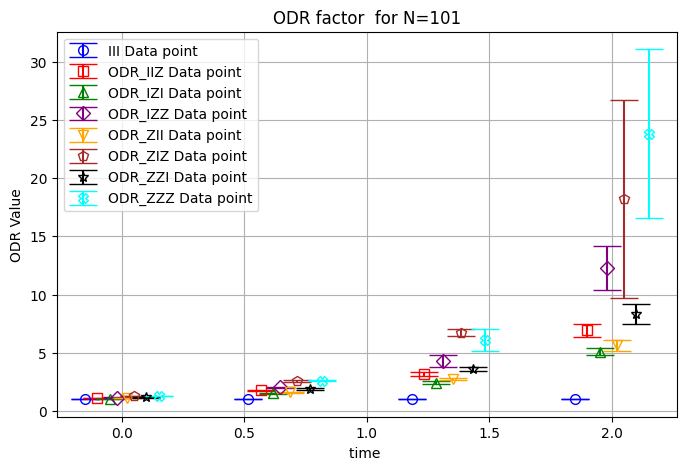

In [7]:
# Split into time and entropy arrays
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.interpolate import PchipInterpolator

mark= np.array(['o', 's', '^', 'D', 'v', 'p', '*', 'X'])
color = np.array(['blue', 'red', 'green', 'purple', 'orange', 'brown', 'black', 'cyan'])

time_1 = np.array(times)
print(time_1)
time = np.array( [0.0, 0.333, 0.666, 1] )*2
ODR_op =  np.array(['III','ODR_IIZ', 'ODR_IZI', 'ODR_IZZ', 'ODR_ZII', 'ODR_ZIZ', 'ODR_ZZI', 'ODR_ZZZ'])
P_op = np.array(['III','IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'])

time_arr = np.linspace(time[0], time[-1], 400)
time_idx_list = np.array([
    time - 0.15,
    time - 0.10,
    time - 0.05,
    time - 0.02,
    time + 0.02,
    time + 0.05,
    time + 0.10,
    time + 0.15
])
# Plot
plt.figure(figsize=(8, 5))
ODR_err_fit_list = []
for i, op in enumerate(ODR_op):
    exp_op = np.array(mean_exp_run1[:, i])
    std_op = np.array(std_exp_run1[:,i])
    print(exp_op)
    ODR_fac_2t = 1/exp_op
    ODR_err = np.zeros(len(time), dtype = float)
    for j in range(len(time)):
        ODR_err[j] = std_op[j] / (exp_op[j]**2)
    
    ODR_fac_2t_UP = ODR_fac_2t  + ODR_err
    ODR_fac_2t_LOW = ODR_fac_2t  - ODR_err

    cubi_err_fit = PchipInterpolator(time, ODR_err)
    ODR_err_fit = cubi_err_fit(time_1)
    ODR_err_fit_list.append(ODR_err_fit)

    cubi_fit =  PchipInterpolator(time, ODR_fac_2t)
    cubi_fit_UP =  PchipInterpolator(time, ODR_fac_2t_UP)
    cubi_fit_LOW =  PchipInterpolator(time, ODR_fac_2t_LOW)
    cubic_fit_op = cubi_fit(time_1)
    ODR_fit_arra = cubi_fit(time_arr)
    ODR_fit_arra_UP = cubi_fit_UP(time_arr)
    ODR_fit_arra_LOW = cubi_fit_LOW(time_arr)
    print(f"{op}_run1Set1 = {np.array2string(cubic_fit_op, separator =',' )}")
    
    #plt.plot(time, ODR_fac_2t, marker= mark[i], color=color[i],linestyle='None', label=f'{op} Data point')
    #plt.plot(time_arr, ODR_fit_arra, '--',  color=color[i], label=f'{op} fit')
    plt.errorbar(time_idx_list[i], ODR_fac_2t, ODR_err, fmt=mark[i], markersize=7, capsize=10,linestyle='None', markerfacecolor='none', color=color[i], label=f'{op} Data point')
    #plt.fill_between(time_arr, ODR_fit_arra_UP, ODR_fit_arra_LOW, color=color[0] , alpha=0.2)

ODR_err_fit_list= np.array(ODR_err_fit_list)
print(f"ODR_err_run1 = {np.array2string(ODR_err_fit_list, separator =',')}")
plt.title(f'ODR factor  for N=101')
plt.grid()
plt.xlabel('time ')
plt.ylabel('ODR Value')
plt.legend()
#plt.savefig(f'ODR_value_vs_time.png')
plt.show()

[0.         0.33333333 0.66666667 1.        ]
[1. 1. 1. 1.]
III_run1Set1 = [1.,1.,1.,1.]
[0.989  0.7975 0.589  0.534 ]
ODR_IIZ_run1Set1 = [1.01112235,1.11119098,1.25423316,1.48457934]
[0.9825 0.883  0.617  0.583 ]
ODR_IZI_run1Set1 = [1.0178117 ,1.05200156,1.1326897 ,1.38105892]
[0.9735 0.7835 0.4995 0.423 ]
ODR_IZZ_run1Set1 = [1.02722137,1.10690269,1.2766964 ,1.62656231]
[0.99   0.8015 0.624  0.4815]
ODR_ZII_run1Set1 = [1.01010101,1.11578579,1.24794562,1.41054816]
[0.985  0.6915 0.4915 0.3185]
ODR_ZIZ_run1Set1 = [1.01522843,1.21272504,1.4466296 ,1.70751581]
[0.9775 0.7545 0.592  0.4425]
ODR_ZZI_run1Set1 = [1.0230179 ,1.16702476,1.32571162,1.4936226 ]
[0.979  0.6365 0.5215 0.338 ]
ODR_ZZZ_run1Set1 = [1.02145046,1.32482714,1.57151702,1.73294978]
ODR_err_run2 = [[0.        ,0.        ,0.        ,0.        ],
 [0.00195769,0.00980743,0.02186521,0.0452896 ],
 [0.00155391,0.00536041,0.01056171,0.01740174],
 [0.0096853 ,0.01157532,0.0166455 ,0.05524393],
 [0.00117815,0.00578377,0.01133559,0.01

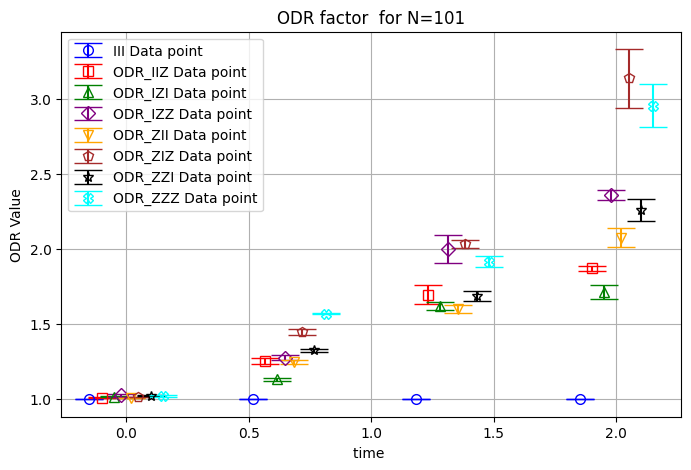

In [8]:
# Split into time and entropy arrays
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.interpolate import PchipInterpolator

mark= np.array(['o', 's', '^', 'D', 'v', 'p', '*', 'X'])
color = np.array(['blue', 'red', 'green', 'purple', 'orange', 'brown', 'black', 'cyan'])

time_1 = np.array(times)
print(time_1)
time = np.array([0.0, 0.333, 0.666, 1] )*2
ODR_op =  np.array(['III','ODR_IIZ', 'ODR_IZI', 'ODR_IZZ', 'ODR_ZII', 'ODR_ZIZ', 'ODR_ZZI', 'ODR_ZZZ'])
P_op = np.array(['III','IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'])

time_arr = np.linspace(time[0], time[-1], 400)
time_idx_list = np.array([
    time - 0.15,
    time - 0.10,
    time - 0.05,
    time - 0.02,
    time + 0.02,
    time + 0.05,
    time + 0.10,
    time + 0.15
])
# Plot
plt.figure(figsize=(8, 5))
ODR_err_fit_list = []
for i, op in enumerate(ODR_op):
    exp_op = np.array(mean_exp_run2[:, i])
    std_op = np.array(std_exp_run2[:,i])
    print(exp_op)
    ODR_fac_2t = 1/exp_op
    ODR_err = np.zeros(len(time), dtype = float)
    for j in range(len(time)):
        ODR_err[j] = std_op[j] / (exp_op[j]**2)
    
    ODR_fac_2t_UP = ODR_fac_2t  + ODR_err
    ODR_fac_2t_LOW = ODR_fac_2t  - ODR_err

    cubi_err_fit = PchipInterpolator(time, ODR_err)
    ODR_err_fit = cubi_err_fit(time_1)
    ODR_err_fit_list.append(ODR_err_fit)

    cubi_fit =  PchipInterpolator(time, ODR_fac_2t)
    cubi_fit_UP =  PchipInterpolator(time, ODR_fac_2t_UP)
    cubi_fit_LOW =  PchipInterpolator(time, ODR_fac_2t_LOW)
    cubic_fit_op = cubi_fit(time_1)
    ODR_fit_arra = cubi_fit(time_arr)
    ODR_fit_arra_UP = cubi_fit_UP(time_arr)
    ODR_fit_arra_LOW = cubi_fit_LOW(time_arr)
    print(f"{op}_run1Set1 = {np.array2string(cubic_fit_op, separator =',' )}")
    
    #plt.plot(time, ODR_fac_2t, marker= mark[i], color=color[i],linestyle='None', label=f'{op} Data point')
    #plt.plot(time_arr, ODR_fit_arra, '--',  color=color[i], label=f'{op} fit')
    plt.errorbar(time_idx_list[i], ODR_fac_2t, ODR_err, fmt=mark[i], markersize=7, capsize=10,linestyle='None', markerfacecolor='none', color=color[i], label=f'{op} Data point')
    #plt.fill_between(time_arr, ODR_fit_arra_UP, ODR_fit_arra_LOW, color=color[0] , alpha=0.2)

ODR_err_fit_list= np.array(ODR_err_fit_list)
print(f"ODR_err_run2 = {np.array2string(ODR_err_fit_list, separator =',')}")
plt.title(f'ODR factor  for N=101')
plt.grid()
plt.xlabel('time ')
plt.ylabel('ODR Value')
plt.legend()
#plt.savefig(f'ODR_value_vs_time.png')
plt.show()